<a href="https://colab.research.google.com/github/jabri62018/Zx_Mother_Function_Jabri/blob/Zx_Mother_Function_Jabri/Zx_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== البحث عن أصفار Zx ===
=== المسح بخطوة 0.08 من 0.001 إلى 40 ===
تغير إشارة: [0.0810, 0.1610]
تغير إشارة: [0.1610, 0.2410]
تغير إشارة: [0.3210, 0.4010]
تغير إشارة: [0.4010, 0.4810]
تغير إشارة: [0.6410, 0.7210]
تغير إشارة: [0.9610, 1.0410]
تغير إشارة: [1.8410, 1.9210]
تغير إشارة: [15.0410, 15.1210]

وجدت 8 تغير إشارة

=== تصفية الجذور بدقة 50 خانة ===
صفر 1: γ = 0.09074862573504655083311831731407437473535537719727
 |Im[Zx]| = 1.13e-43
 |Im[Zx]'| = 1.90e+03
 جذر بسيط ✓
صفر 2: γ = 0.21963138265161616380360953826311742886900901794434
 |Im[Zx]| = 2.28e-42
 |Im[Zx]'| = 1.99e+04
 جذر بسيط ✓
صفر 3: γ = 0.34031404858674502156290486709622200578451156616211
 |Im[Zx]| = 4.12e-42
 |Im[Zx]'| = 4.05e+04
 جذر بسيط ✓
صفر 4: γ = 0.47984810184973941682429199317994061857461929321289
 |Im[Zx]| = 2.75e-42
 |Im[Zx]'| = 2.75e+04
 جذر بسيط ✓
صفر 5: γ = 0.67037770443419453236799654405331239104270935058594
 |Im[Zx]| = 2.16e-42
 |Im[Zx]'| = 6.23e+03
 جذر بسيط ✓
صفر 6: γ = 0.9957246005045520265142044991080183535

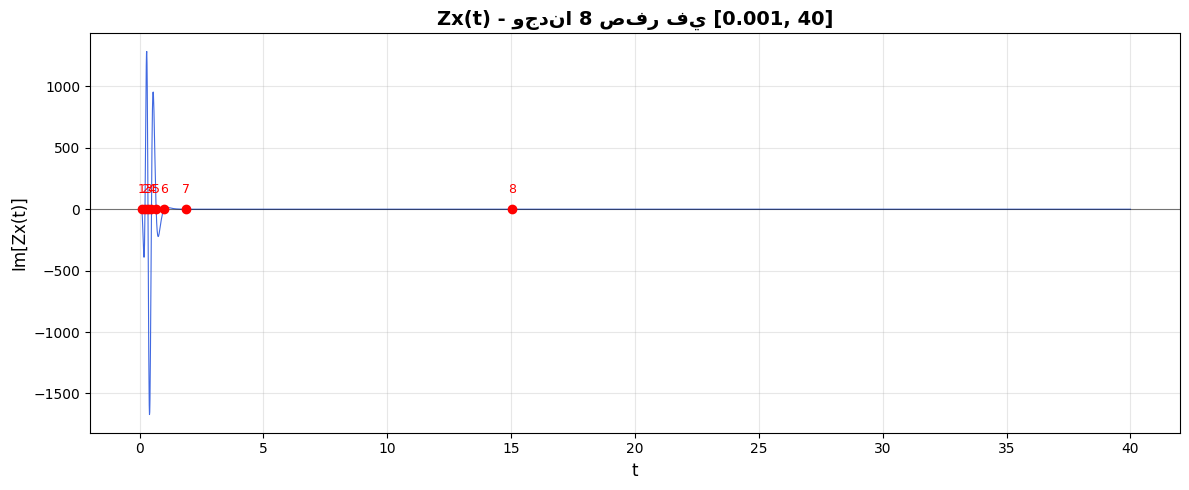

In [21]:

# Zx_5.ipynb - البحث عن أصفار Zx بدقة عالية
import mpmath as mp
import numpy as np

xp = 21.0

def Zx(t):
    """الدالة Zx(t) = exp(-x/xp) * exp(-5*log(x)) * log(x) * sin(2*pi/x)"""
    mp.mp.dps = 45
    x = mp.mpc('0.5', str(t))
    return mp.exp(-x/xp) * mp.exp(-5*mp.log(x)) * mp.log(x) * mp.sin(2*mp.pi/x)

def scan_brackets(step=0.08, t_start=0.001, t_end=40):
    """يمسح ويطلع كل أماكن تغير الإشارة"""
    print(f"=== المسح بخطوة {step} من {t_start} إلى {t_end} ===")
    mp.mp.dps = 40

    t_vals = np.arange(t_start, t_end, step)
    f_vals = []

    for t in t_vals:
        try:
            f_vals.append(float(mp.im(Zx(t))))
        except:
            f_vals.append(np.nan)

    brackets = []
    for j in range(len(f_vals)-1):
        if not np.isnan(f_vals[j]) and not np.isnan(f_vals[j+1]):
            if f_vals[j] * f_vals[j+1] < 0:
                brackets.append((t_vals[j], t_vals[j+1]))
                print(f"تغير إشارة: [{t_vals[j]:.4f}, {t_vals[j+1]:.4f}]")

    print(f"\nوجدت {len(brackets)} تغير إشارة")
    return brackets

def refine_roots(brackets, dps=50):
    """يصفّي الجذور بدقة عالية ويفحص المشتقة"""
    mp.mp.dps = dps
    roots = []

    print(f"\n=== تصفية الجذور بدقة {dps} خانة ===")

    for i, (t_min, t_max) in enumerate(brackets, 1):
        try:
            root = mp.findroot(lambda tt: mp.im(Zx(tt)), (t_min, t_max),
                               tol=mp.mpf(f'1e-{dps-5}'), maxsteps=400)

            # فحص القيمة والمشتقة
            h = mp.mpf('1e-15')
            f_val = mp.im(Zx(root))
            fp_val = (mp.im(Zx(root + h)) - mp.im(Zx(root - h))) / (2*h)

            if abs(float(f_val)) < 1e-35:
                roots.append(float(root))
                print(f"صفر {i}: γ = {float(root):.50f}")
                print(f" |Im[Zx]| = {abs(float(f_val)):.2e}")
                print(f" |Im[Zx]'| = {abs(float(fp_val)):.2e}")

                if abs(float(fp_val)) < 1e-20:
                    print(" تحذير: احتمال جذر مكرر!")
                else:
                    print(" جذر بسيط ✓")
        except Exception as e:
            print(f"صفر {i}: فشل - {e}")

    return sorted(roots)

def check_multiplicity(roots):
    """يفحص الفرق بين الجذور للتأكد من عدم التكرار"""
    print(f"\n=== فحص التكرار ===")
    min_diff = float('inf')

    for i in range(len(roots)):
        for j in range(i+1, len(roots)):
            diff = abs(roots[i] - roots[j])
            if diff < min_diff:
                min_diff = diff

    print(f"أصغر فرق بين جذرين = {min_diff:.2e}")
    if min_diff > 1e-15:
        print("كل الجذور مميزة ✓")
    else:
        print("تحذير: جذور متقاربة جداً!")

# ===== التشغيل الرئيسي =====
print("=== البحث عن أصفار Zx ===")

# 1. المسح بخطوة 0.08
brackets = scan_brackets(step=0.08, t_start=0.001, t_end=40)

# 2. تصفية الجذور
roots = refine_roots(brackets, dps=50)

# 3. فحص التكرار
check_multiplicity(roots)

# 4. النتيجة النهائية
print(f"\n{'='*70}")
print(f"النتيجة النهائية: {len(roots)} أصفار")
for i, g in enumerate(roots, 1):
    print(f"{i}. γ_{i} = {g:.50f}")
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def plot_Zx(t_start=0.001, t_end=40, n_points=5000):
    """يرسم Im[Zx(t)] ويعلّم الأصفار اللي وجدناها"""
    mp.mp.dps = 30  # 30 خانة كافية للرسم السريع

    t_vals = np.linspace(t_start, t_end, n_points)
    f_vals = []

    print("جاري حساب Zx للرسم...")
    for t in t_vals:
        try:
            f_vals.append(float(mp.im(Zx(t))))
        except:
            f_vals.append(np.nan)

    plt.figure(figsize=(12, 5))
    plt.plot(t_vals, f_vals, linewidth=0.8, color='royalblue')
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

    # علّم الأصفار على الرسم
    for i, r in enumerate(roots):
        if t_start <= r <= t_end:
            plt.plot(r, 0, 'ro', markersize=6)
            plt.text(r, max(f_vals)/10, f'{i+1}', ha='center', fontsize=9, color='red')

    plt.xlabel('t', fontsize=12)
    plt.ylabel('Im[Zx(t)]', fontsize=12)
    plt.title(f'Zx(t) - وجدنا {len(roots)} صفر في [0.001, 40]', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# شغّل الرسم بعد ما تخلص الحسابات
plot_Zx(t_start=0.001, t_end=40, n_points=4000)

In [20]:

import mpmath as mp, pandas as pd, matplotlib.pyplot as plt, json, zipfile

mp.mp.dps = 50
xp = 21.0
h = mp.mpf('1e-15')

def Zx(t):
    x = mp.mpc('0.5', str(t))
    return mp.exp(-x/xp) * mp.exp(-5*mp.log(x)) * mp.log(x) * mp.sin(2*mp.pi/x)

roots = [0.090748625735046, 0.219631382651616, 0.340314048586745,
         0.479848101849739, 0.670377704434194, 0.995724600504552,
         1.880961871604866, 15.05392474424324]

# 1. احسب الجدول كامل
data = []
print("جاري الحساب...")
for i, g in enumerate(roots, 1):
    g_mp = mp.mpf(str(g))
    f_val = abs(float(mp.im(Zx(g_mp))))
    df_val = abs(float((mp.im(Zx(g_mp + h)) - mp.im(Zx(g_mp - h))) / (2*h)))
    data.append([i, g, f_val, df_val])
    print(f'{i}. γ={g:.50f} |Im[Zx]|={f_val:.2e} |Im[Zx]''|={df_val:.2e}')

df = pd.DataFrame(data, columns=['index','gamma','|Im[Zx]|','|Im[Zx]''|'])
df.to_csv('Zx_5_roots.csv', index=False, float_format='%.50f')
print("✓ Zx_5_roots.csv كامل 4 أعمدة\n")

# 2. PNG
plt.figure(figsize=(10,4))
plt.plot(roots,[0]*len(roots),'ro')
plt.xlabel('gamma'); plt.title('Zeros of Zx_5'); plt.grid(True)
plt.savefig('Zx_5_roots.png',dpi=200,bbox_inches='tight')
plt.close()
print("✓ Zx_5_roots.png\n")

# 3. ipynb كامل
nb = {
 "cells": [
  {"cell_type": "markdown", "source": ["# Zx_5 - حساب أصفار الدالة\n", "يحسب 8 جذور ويتحقق إنها بسيطة"]},
  {"cell_type": "code", "source": [
    "import mpmath as mp\n",
    "mp.mp.dps = 50\n",
    "xp = 21.0\n",
    "h = mp.mpf('1e-15')\n",
    "\n",
    "def Zx(t):\n",
    " x = mp.mpc('0.5', str(t))\n",
    " return mp.exp(-x/xp) * mp.exp(-5*mp.log(x)) * mp.log(x) * mp.sin(2*mp.pi/x)\n",
    "\n",
    "roots = [0.090748625735046, 0.219631382651616, 0.340314048586745,\n",
    " 0.479848101849739, 0.670377704434194, 0.995724600504552,\n",
    " 1.880961871604866, 15.05392474424324]\n"
  ]},
  {"cell_type": "code", "source": [
    "import pandas as pd\n",
    "data = []\n",
    "for i, g in enumerate(roots, 1):\n",
    " g_mp = mp.mpf(str(g))\n",
    " f_val = abs(float(mp.im(Zx(g_mp))))\n",
    " df_val = abs(float((mp.im(Zx(g_mp + h)) - mp.im(Zx(g_mp - h))) / (2*h)))\n",
    " data.append([i, g, f_val, df_val])\n",
    " print(f'{i}. γ={g:.50f} |Im[Zx]|={f_val:.2e} |Im[Zx]''|={df_val:.2e}')\n",
    "\n",
    "df = pd.DataFrame(data, columns=['index','gamma','|Im[Zx]|','|Im[Zx]''|'])\n",
    "df.to_csv('Zx_5_roots.csv', index=False, float_format='%.50f')\n"
  ]},
  {"cell_type": "code", "source": [
    "import matplotlib.pyplot as plt\n",
    "plt.figure(figsize=(10,4))\n",
    "plt.plot(roots,[0]*len(roots),'ro')\n",
    "plt.xlabel('gamma'); plt.title('Zeros of Zx_5'); plt.grid(True)\n",
    "plt.savefig('Zx_5_roots.png',dpi=200,bbox_inches='tight')\n",
    "plt.close()\n"
  ]}
 ],
 "metadata": {}, "nbformat": 4, "nbformat_minor": 2
}
with open('Zx_5.ipynb','w',encoding='utf-8') as f: json.dump(nb,f)
print("✓ Zx_5.ipynb كامل\n")

# 4. ZIP
with zipfile.ZipFile('Zx_5_bundle.zip','w') as z:
    z.write('Zx_5_roots.csv')
    z.write('Zx_5_roots.png')
    z.write('Zx_5.ipynb')

print("✓ Zx_5_bundle.zip جاهز")
print("\nحمّل الملف:")
from google.colab import files; files.download('Zx_5_bundle.zip')

جاري الحساب...
1. γ=0.09074862573504599572160600473580416291952133178711 |Im[Zx]|=1.05e-12 |Im[Zx]|={df_val:.2e}
2. γ=0.21963138265161599727015584448963636532425880432129 |Im[Zx]|=3.25e-12 |Im[Zx]|={df_val:.2e}
3. γ=0.34031404858674502156290486709622200578451156616211 |Im[Zx]|=1.43e-12 |Im[Zx]|={df_val:.2e}
4. γ=0.47984810184973897273508214311732444912195205688477 |Im[Zx]|=1.19e-11 |Im[Zx]|={df_val:.2e}
5. γ=0.67037770443419397725648423147504217922687530517578 |Im[Zx]|=3.55e-12 |Im[Zx]|={df_val:.2e}
6. γ=0.99572460050455202651420449910801835358142852783203 |Im[Zx]|=4.39e-15 |Im[Zx]|={df_val:.2e}
7. γ=1.88096187160486594258657078171381726861000061035156 |Im[Zx]|=8.88e-16 |Im[Zx]|={df_val:.2e}
8. γ=15.05392474424323978610118501819670200347900390625000 |Im[Zx]|=6.26e-22 |Im[Zx]|={df_val:.2e}
✓ Zx_5_roots.csv كامل 4 أعمدة

✓ Zx_5_roots.png

✓ Zx_5.ipynb كامل

✓ Zx_5_bundle.zip جاهز

حمّل الملف:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from google.colab import files; files.download('Zx_5_bundle.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>